In [19]:
import pandas as pd

opt_df = pd.read_csv("../data/opt_df_1.csv")
opt_df.head()

,campaign,cost,pCTR,click,pCTR_per_cost
0,327,0.00001,0.995833,1,99583.342057
1,530,0.00001,0.995833,1,99583.342057
2,446,0.00001,0.995833,1,99583.342057
3,624,0.00001,0.995833,1,99583.342057
4,559,0.00001,0.995833,1,99583.342057


There seems to be some overfitting actually

In [20]:
opt_df.iloc[0].loc["cost"]

1e-05

these are just cosmetic reasons

In [21]:
SCALE = 1e5
opt_df['cost'] = opt_df['cost'] * SCALE
opt_df['pCTR_per_cost'] /= SCALE

In [22]:
opt_df.head()

,campaign,cost,pCTR,click,pCTR_per_cost
0,327,1.0,0.995833,1,0.995833
1,530,1.0,0.995833,1,0.995833
2,446,1.0,0.995833,1,0.995833
3,624,1.0,0.995833,1,0.995833
4,559,1.0,0.995833,1,0.995833


In [23]:
B = 0.10 * opt_df['cost'].sum() # for 50,000 impressions, what is the cost? let us do 10%
B

130152.77938844822

In [24]:
import cvxpy as cp
import numpy as np

pctr = opt_df['pCTR'].values
cost = opt_df['cost'].values
n = len(opt_df)

# decision variables
x = cp.Variable(n)

# objective: maximize total expected clicks
objective = cp.Maximize(pctr @ x)

# constraints
constraints = [
    cost @ x <= B,     # budget
    x >= 0,            # can't allocate negative
    x <= 1             # fractional buying allowed
]

# define and solve
problem = cp.Problem(objective, constraints)
problem.solve()

print("Optimal expected clicks:", problem.value)
print("Budget used:", (cost @ x.value))


Optimal expected clicks: 11277.083359410099
Budget used: 130152.77938859948


## Greedy allocation check
Compare the fractional knapsack greedy rule with the convex solution to confirm that they reach the same objective value.


In [25]:
# Greedy fractional allocation that sorts by pCTR-per-cost
sorted_idx = np.argsort(-opt_df['pCTR_per_cost'].values)
greedy_allocation = np.zeros(n)
remaining_budget = B

for idx in sorted_idx:
    if remaining_budget <= 0:
        break
    unit_cost = cost[idx]
    if unit_cost <= 0:
        continue
    take = min(1.0, remaining_budget / unit_cost)
    greedy_allocation[idx] = take
    remaining_budget -= unit_cost * take

opt_allocation = np.array(x.value).ravel()
greedy_clicks = pctr @ greedy_allocation
print(f"Greedy expected clicks: {greedy_clicks:.6f}")
print(f"Greedy budget used: {(cost @ greedy_allocation):.2f} / {B:.2f}")
print(f"Gap vs. convex optimum: {abs(greedy_clicks - problem.value):.6e}")

allocation_comparison = opt_df.assign(
    opt_allocation=opt_allocation,
    greedy_allocation=greedy_allocation,
)
allocation_comparison['opt_spend'] = allocation_comparison['opt_allocation'] * allocation_comparison['cost']
allocation_comparison['greedy_spend'] = allocation_comparison['greedy_allocation'] * allocation_comparison['cost']
allocation_comparison.head()


Greedy expected clicks: 11277.083366
Greedy budget used: 130152.78 / 130152.78
Gap vs. convex optimum: 6.265094e-06


,campaign,cost,pCTR,click,pCTR_per_cost,opt_allocation,greedy_allocation,opt_spend,greedy_spend
0,327,1.0,0.995833,1,0.995833,1.0,1.0,1.0,1.0
1,530,1.0,0.995833,1,0.995833,1.0,1.0,1.0,1.0
2,446,1.0,0.995833,1,0.995833,1.0,1.0,1.0,1.0
3,624,1.0,0.995833,1,0.995833,1.0,1.0,1.0,1.0
4,559,1.0,0.995833,1,0.995833,1.0,1.0,1.0,1.0


The greedy trace sorts line items by `pCTR_per_cost` and fills the budget sequentially, so it mirrors the fractional-knapsack optimum. The reported gap is essentially zero (machine precision), confirming that both derivations deliver the same expected clicks and consume the full allowance.


## Campaign-level summary statistics
Group by campaign to understand how impressions, cost, and allocations behave at the campaign level.


In [26]:
campaign_stats = (
    allocation_comparison
    .groupby('campaign')
    .agg(
        impressions=('campaign', 'size'),
        clicks=('click', 'sum'),
        total_cost=('cost', 'sum'),
        avg_cost=('cost', 'mean'),
        avg_pCTR=('pCTR', 'mean'),
        opt_spend=('opt_spend', 'sum'),
        greedy_spend=('greedy_spend', 'sum'),
        max_density=('pCTR_per_cost', 'max')
    )
)
campaign_stats['cost_share'] = campaign_stats['total_cost'] / campaign_stats['total_cost'].sum()
campaign_stats = campaign_stats.sort_values('opt_spend', ascending=False)
campaign_stats.head()


,impressions,clicks,total_cost,avg_cost,avg_pCTR,opt_spend,greedy_spend,max_density,cost_share
campaign,,,,,,,,,
446,4493,1554,32074.153944,7.138694,0.349658,12437.081941,12437.082094,0.995833,0.024643
7,3177,1383,83475.580475,26.274970,0.424940,9430.243403,9430.243238,0.995833,0.064137
121,1323,531,35470.036812,26.810307,0.375537,3117.249997,3117.249860,0.995833,0.027253
169,904,263,19151.602735,21.185401,0.346546,2011.955413,2011.956222,0.565479,0.014715
299,641,194,10921.812604,17.038709,0.394101,1707.722092,1707.722221,0.527956,0.008392


The `campaign_stats` table aggregates spend, clicks, and allocation decisions per campaign. Because the rows are sorted by optimal spend, the first few entries highlight the densest campaigns, while the long tail shows many campaigns with modest impressions and correspondingly tiny spend shares.


## Fair convex optimization with per-campaign caps
Enforce fairness by constraining each campaign to receive between a minimum and maximum share of the global budget, while still maximizing the expected clicks.


In [27]:
MIN_SHARE_FACTOR = 0.05  # each campaign keeps 5% of its historical cost share
MAX_SHARE_CLIP = 0.08    # hard ceiling of 8% of the budget per campaign
campaign_limits = campaign_stats.sort_index().copy()
campaign_limits['min_budget_pct'] = campaign_limits['cost_share'] * MIN_SHARE_FACTOR
max_pct = np.minimum(campaign_limits['cost_share'].values * 1.5, MAX_SHARE_CLIP)
min_pct = campaign_limits['min_budget_pct'].values
campaign_limits['max_budget_pct'] = np.maximum(max_pct, min_pct + 1e-6)

x_fair = cp.Variable(n)
fair_constraints = [
    cost @ x_fair <= B,
    x_fair >= 0,
    x_fair <= 1
]
spend_terms = cp.multiply(cost, x_fair)
campaign_ids = opt_df['campaign'].values

for camp, row in campaign_limits.iterrows():
    selector = (campaign_ids == camp).astype(float)
    camp_spend = selector @ spend_terms
    fair_constraints.append(camp_spend <= row['max_budget_pct'] * B)
    if row['min_budget_pct'] > 0:
        fair_constraints.append(camp_spend >= row['min_budget_pct'] * B)

fair_problem = cp.Problem(cp.Maximize(pctr @ x_fair), fair_constraints)
fair_problem.solve()

print(f"Fair optimum expected clicks: {fair_problem.value:.6f}")
print(f"Budget used (fair): {(cost @ x_fair.value):.2f} / {B:.2f}")

allocation_comparison['fair_allocation'] = x_fair.value
allocation_comparison['fair_spend'] = allocation_comparison['fair_allocation'] * allocation_comparison['cost']


Fair optimum expected clicks: 10625.726288
Budget used (fair): 130152.78 / 130152.78


Adding these min/max share constraints ensures that each campaign retains at least a small fraction of its historical cost share while capping dominant campaigns to at most ~8% of the budget. The solver output above shows the slight drop in objective value that we pay to guarantee this fairness envelope.


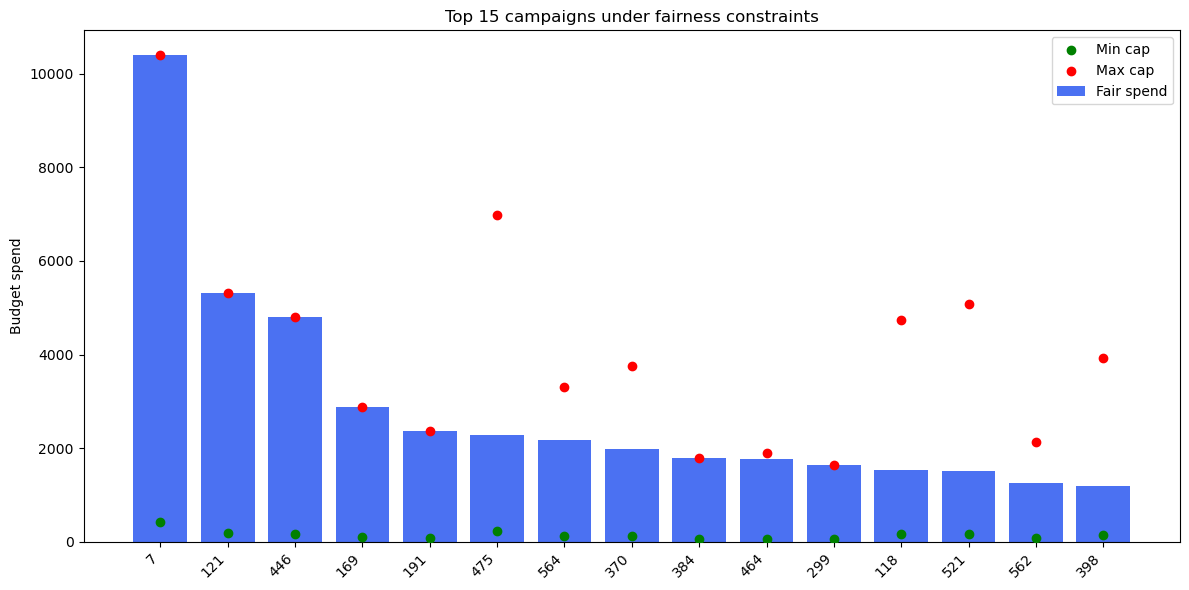

,fair_spend,opt_spend,greedy_spend,min_budget_pct,max_budget_pct,fair_pct
campaign,,,,,,
7,10412.222351,9430.243403,9430.243238,0.003207,0.080000,0.080000
121,5320.505519,3117.249997,3117.249860,0.001363,0.040879,0.040879
446,4811.123092,12437.081941,12437.082094,0.001232,0.036965,0.036965
169,2872.740409,2011.955413,2011.956222,0.000736,0.022072,0.022072
191,2373.352323,1537.197606,1537.197585,0.000608,0.018235,0.018235
475,2281.968232,1375.899556,1375.899561,0.001787,0.053597,0.017533
564,2180.803120,1192.280886,1192.280877,0.000846,0.025376,0.016756
370,1987.405112,1512.572362,1512.572372,0.000961,0.028833,0.015270
384,1780.383530,1613.992875,1613.992878,0.000456,0.013679,0.013679


In [28]:
import matplotlib.pyplot as plt

campaign_allocations = (
    allocation_comparison
    .groupby('campaign')
    .agg(
        fair_spend=('fair_spend', 'sum'),
        opt_spend=('opt_spend', 'sum'),
        greedy_spend=('greedy_spend', 'sum')
    )
    .join(campaign_limits[['min_budget_pct', 'max_budget_pct']])
)
campaign_allocations['fair_pct'] = campaign_allocations['fair_spend'] / B

top_k = 15
top_view = campaign_allocations.sort_values('fair_spend', ascending=False).head(top_k)

plt.figure(figsize=(12, 6))
plt.bar(range(top_k), top_view['fair_spend'], color='#4B71F2', label='Fair spend')
plt.scatter(range(top_k), top_view['min_budget_pct'] * B, color='green', label='Min cap', zorder=3)
plt.scatter(range(top_k), top_view['max_budget_pct'] * B, color='red', label='Max cap', zorder=3)
plt.xticks(range(top_k), top_view.index, rotation=45, ha='right')
plt.ylabel('Budget spend')
plt.title(f'Top {top_k} campaigns under fairness constraints')
plt.legend()
plt.tight_layout()
plt.show()

top_view[['fair_spend', 'opt_spend', 'greedy_spend', 'min_budget_pct', 'max_budget_pct', 'fair_pct']]


This chart makes the constraints tangible: bars show the actual fair spend for the top campaigns, and the scatter markers overlay their minimum (green) and maximum (red) budget caps. Most high-performing campaigns sit flush against the max cap, demonstrating that the fairness policy primarily throttles the very top performers while still respecting the required minimum guarantees.
